In [1]:
import numpy as np
import matplotlib.pyplot as pl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from dynamics_lnv import *

import colorsys
import matplotlib.colors as mcolors

In [2]:
#### Plot settings ####

pl.rcParams['mathtext.fontset'] = 'stix'
pl.rcParams['font.family'] = 'STIXGeneral'

fontsizelegend = 14
fontsizeaxlabel = 24
fontsizeticks = 20

lw = 2. # linewidth

root = 'plots/' #folder to save plots in

# my colour palette
my_colors = {'red':'#b4212a','black':'black','blue':'#2f859a','orange':'#E68106','yellow':'#FFC000','purple':'#7A57A9', 'green':'#228B22'}

# orders
colors_star = [my_colors["yellow"],my_colors["red"],my_colors["green"],my_colors["blue"],my_colors["purple"]]
colors_quad = [my_colors["red"],my_colors["blue"],my_colors["green"]]

In [3]:
# Helper function to adjust tone of a colour
def adjust_lightness(color, amount=0.5):
    """
    amount < 1: darker
    amount > 1: lighter
    """
    # Convert hex/name to RGB
    c = mcolors.to_rgb(color)
    # Convert to HLS
    h, l, s = colorsys.rgb_to_hls(*c)
    # Adjust Lightness
    l = max(0, min(1, l * amount))
    # Convert back to RGB
    return colorsys.hls_to_rgb(h, l, s)

# Quadratic

In [6]:
###### setup ######

colors = colors_quad # choose colours order

pot = "Quad"

# initial conditions
v0 = 1.
sin2b0 = 1. #bounce
T0 = 0.

V01 = (1.21e-6)**2
phi01 = 0.97
V02 = 3.6e-2
frac = 0.99 # fraction of energy in potential at bounce
phi02 = np.sqrt(2*frac*rhoc/V02) # potential dom
V03 = V01
phi03 = 5.45

In [7]:
# time array
ti = 0.
Nts = int(5e3)
pti = 0

print('case 1')
ptf = 8.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f1 = effdynamics(v0,phi01,T0,1.,ts,(pot,V01))

print('\ncase 2')
ptf = 3.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f2 = effdynamics(v0,phi02,T0,1.,ts,(pot,V02))

print('\ncase 3')
ptf = 8.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f3 = effdynamics(v0,phi03,T0,-1.,ts,(pot,V03))

case 1
CPU times: user 26.5 ms, sys: 104 µs, total: 26.6 ms
Wall time: 26.3 ms

case 2
CPU times: user 27.6 ms, sys: 0 ns, total: 27.6 ms
Wall time: 27.6 ms

case 3
CPU times: user 24 ms, sys: 0 ns, total: 24 ms
Wall time: 24 ms


In [8]:
##### extract all info from integration #####

#--- extract vars from sols ---#
lnvt1, phit1, piphit1, Tt1 = sol_f1.y
lnvt2, phit2, piphit2, Tt2 = sol_f2.y
lnvt3, phit3, piphit3, Tt3 = sol_f3.y
vt1 = np.exp(lnvt1)
vt2 = np.exp(lnvt2)
vt3 = np.exp(lnvt3)

#--- other derived quantities ---#
Ht1,aHt1,iinf1,iend1,lna1,zppzt1_h,zppzt1_d,zppzt1,com_rct1,NT1,kmin1,kmax1 = extract_eff_info(sol_f1,(pot,V01))
Ht2,aHt2,iinf2,iend2,lna2,zppzt2_h,zppzt2_d,zppzt2,com_rct2,NT2,kmin2,kmax2 = extract_eff_info(sol_f2,(pot,V02))
Ht3,aHt3,iinf3,iend3,lna3,zppzt3_h,zppzt3_d,zppzt3,com_rct3,NT3,kmin3,kmax3 = extract_eff_info(sol_f3,(pot,V03))

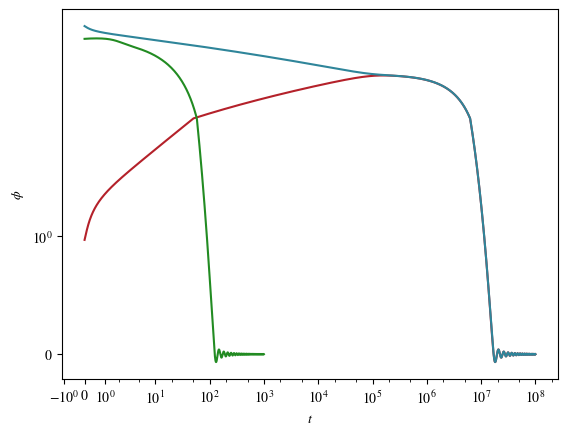

70.01429842184648
70.76383844567137
70.13740490066357


In [20]:
### check to see that all have reached end of inflation
pl.figure()
pl.plot(sol_f1.t,phit1,color=colors[0])
pl.plot(sol_f2.t,phit2,color=colors[2])
pl.plot(sol_f3.t,phit3,color=colors[1])
pl.xscale('asinh')
pl.yscale('symlog')
pl.xlabel(r'$t$')
pl.ylabel(r'$\phi$')
pl.show()

# efolds at end of inflation
print(lna1[iend1])
print(lna2[iend2])
print(lna3[iend3])

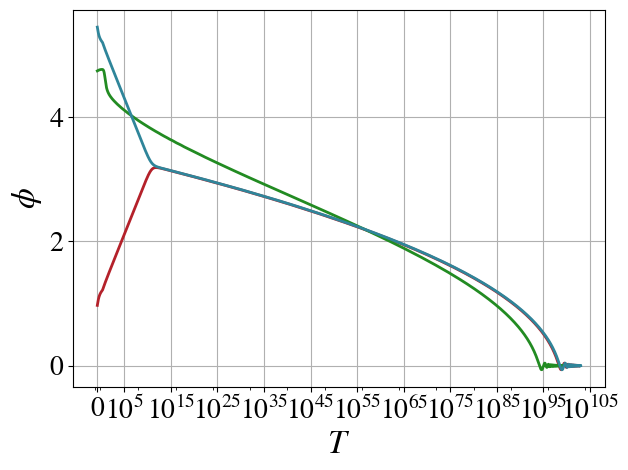

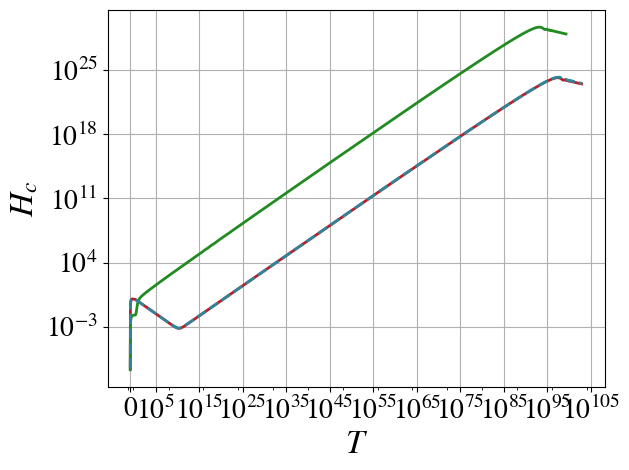

In [19]:
#### Background plots

pl.figure()
pl.plot(Tt1,phit1,linewidth=lw,color=colors[0])
pl.plot(Tt2,phit2,linewidth=lw,color=colors[2])
pl.plot(Tt3,phit3,linewidth=lw,color=colors[1])
pl.xscale('symlog')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$\phi$',fontsize = fontsizeaxlabel)
pl.tick_params(labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,108,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-phiT.pdf'
#pl.savefig(fname,dpi = 250, transparent=True)
pl.show()


pl.figure()
pl.plot(Tt1,aHt1,linewidth=lw,color=colors[0])
pl.plot(Tt2,aHt2,linewidth=lw,color=colors[2])
pl.plot(Tt3,aHt3,'--',linewidth=lw,color=colors[1])
pl.xscale('symlog')
pl.yscale('log')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$H_c$',fontsize = fontsizeaxlabel)
pl.tick_params(labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,108,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-aHT.pdf'
#pl.savefig(fname,dpi = 250, transparent=True)
pl.show()

# Starobinsky

In [21]:
###### setup ######

colors = colors_star # choose colours order

pot = "Star"

# initial conditions
v0 = 1.
sin2b0 = 1. #bounce
T0 = 0.

## Different cases
V01 = 1.77e-13
phi01 = -1.46
V02 = 0.85*rhoc
phi02 = 1.8
V03 = 0.1
phi03 = .81 
V03_down = V01
phi03_down = 3.634

In [23]:
###### numerical integrations ######

# time array
ti = 0.
Nts = int(1e6)
pti = 0

# case 1 (up)
print('case 1')
ptf = 8. # power of t_end
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f1 = effdynamics(v0,phi01,T0,-1.,ts,(pot,V01))

# case 1 with opposite pi_phi (down)
print('\ncase 1 down')
ptf = 8. # power of t_end
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f1_down = effdynamics(v0,phi01,T0,1.,ts,(pot,V01))

# case 2
print('\ncase 2')
ptf = 2.3
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f2 = effdynamics(v0,phi02,T0,-1.,ts,(pot,V02),'BDF')

# case 3 (up)
print('\ncase 3')
ptf = 2.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f3 = effdynamics(v0,phi03,T0,1.,ts,(pot,V03))

# case 1 with opposite pi_phi (down)
print('\ncase 3 down')
ptf = 8.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f3_down = effdynamics(v0,phi03_down,T0,-1.,ts,(pot,V03_down))

case 1
CPU times: user 844 ms, sys: 1.22 s, total: 2.07 s
Wall time: 137 ms

case 1 down
CPU times: user 752 ms, sys: 1.08 s, total: 1.83 s
Wall time: 117 ms

case 2
CPU times: user 1.2 s, sys: 1.58 s, total: 2.78 s
Wall time: 337 ms

case 3
CPU times: user 433 ms, sys: 710 ms, total: 1.14 s
Wall time: 77.7 ms

case 3 down
CPU times: user 711 ms, sys: 1.04 s, total: 1.75 s
Wall time: 111 ms


In [24]:
##### extract all info from integration #####

#--- extract vars from sols ---#
lnvt1, phit1, piphit1, Tt1 = sol_f1.y
lnvt2, phit2, piphit2, Tt2 = sol_f2.y
lnvt3, phit3, piphit3, Tt3 = sol_f3.y
lnvt1_down, phit1_down, piphit1_down, Tt1_down = sol_f1_down.y
lnvt3_down, phit3_down, piphit3_down, Tt3_down = sol_f3_down.y
vt1 = np.exp(lnvt1)
vt2 = np.exp(lnvt2)
vt3 = np.exp(lnvt3)
vt1_down = np.exp(lnvt1_down)
vt3_down = np.exp(lnvt3_down)

#--- other derived quantities ---#
Ht1,aHt1,iinf1,iend1,lna1,zppzt1_h,zppzt1_d,zppzt1,com_rct1,NT1,kmin1,kmax1 = extract_eff_info(sol_f1,(pot,V01))
Ht2,aHt2,iinf2,iend2,lna2,zppzt2_h,zppzt2_d,zppzt2,com_rct2,NT2,kmin2,kmax2 = extract_eff_info(sol_f2,(pot,V02))
Ht3,aHt3,iinf3,iend3,lna3,zppzt3_h,zppzt3_d,zppzt3,com_rct3,NT3,kmin3,kmax3 = extract_eff_info(sol_f3,(pot,V03))
Ht1_down,aHt1_down,iinf1_down,iend1_down,lna1_down,zppzt1_h_down,zppzt1_d_down,zppzt1_down,com_rct1_down,NT1_down,kmin1_down,kmax1_down = extract_eff_info(sol_f1_down,(pot,V01))
Ht3_down,aHt3_down,iinf3_down,iend3_down,lna3_down,zppzt3_h_down,zppzt3_d_down,zppzt3_down,com_rct3_down,NT3_down,kmin3_down,kmax3_down = extract_eff_info(sol_f3_down,(pot,V03))

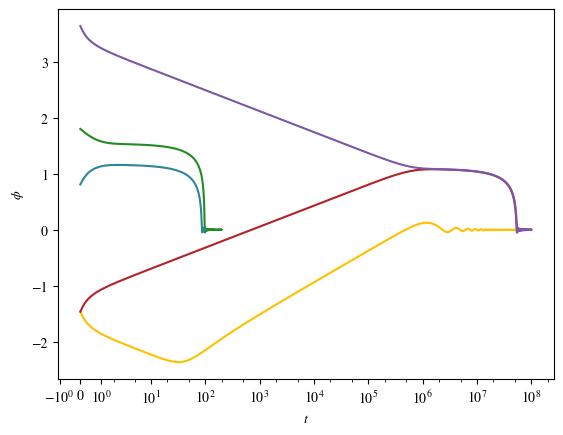

12.538760958321824
66.2585345524981
66.69270397027624
66.34050990487812
66.93722086534308


In [27]:
### check to see that all have reached end of inflation
pl.figure()
pl.plot(sol_f1.t,phit1,color=colors[0])
pl.plot(sol_f1_down.t,phit1_down,color=colors[1])
pl.plot(sol_f2.t,phit2,color=colors[2])
pl.plot(sol_f3.t,phit3,color=colors[3])
pl.plot(sol_f3_down.t,phit3_down,color=colors[4])
pl.xscale('asinh')
pl.xlabel(r'$t$')
pl.ylabel(r'$\phi$')
pl.show()

#### and number of efolds at end of inflation
print(lna1[iend1]) # can't get enough inflation with this one, won't plot it in next plots
print(lna1_down[iend1_down])
print(lna2[iend2])
print(lna3[iend3])
print(lna3_down[iend3_down])

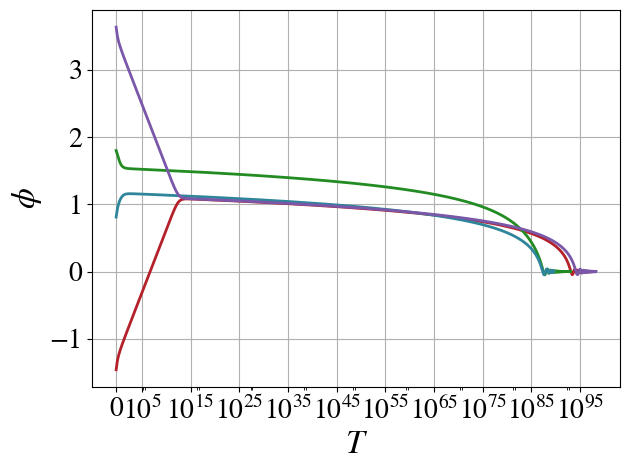

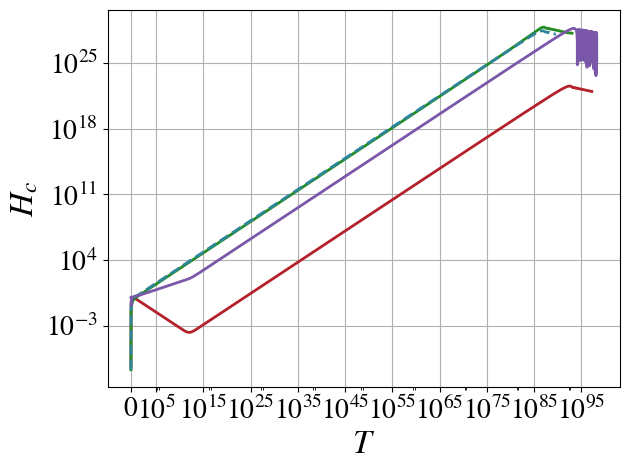

In [28]:
#### Background plots

pl.figure()
#pl.plot(Tt1,phit1,linewidth=lw,color=colors[0])
pl.plot(Tt1_down,phit1_down,linewidth=lw,color=colors[1])
pl.plot(Tt2,phit2,linewidth=lw,color=colors[2])
pl.plot(Tt3,phit3,linewidth=lw,color=colors[3])
pl.plot(Tt3_down,phit3_down,linewidth=lw,color=colors[4])
pl.xscale('asinh')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$\phi$',fontsize = fontsizeaxlabel)
pl.tick_params(axis = 'both',labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,102,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-phiT.pdf'
#pl.savefig(fname,dpi = 250, transparent=True)
pl.show()

pl.figure()
#pl.plot(Tt1,aHt1,'--',linewidth=lw,color=colors[0],zorder=3)
pl.plot(Tt1_down,aHt1_down,linewidth=lw,color=colors[1],zorder=2)
pl.plot(Tt2,aHt2,linewidth=lw,color=colors[2])
pl.plot(Tt3,aHt3,'--',linewidth=lw,color=colors[3])
pl.plot(Tt3_down,aHt3_down,linewidth=lw,color=colors[4])
pl.xscale('asinh')
pl.yscale('log')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$H_c$',fontsize = fontsizeaxlabel)
pl.tick_params(axis = 'both',labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,102,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-aHT.pdf'
#pl.savefig(fname,dpi = 250, transparent=True)
pl.show()

# alpha attractors

In [4]:
###### setup ######

colors = colors_star # choose colour orders

# parameters of potential
pot = "Alpha" # options are "Exp-Phi", "Star", "Monod", "Quad", "Alpha"
alpha = 7.

# initial conditions
v0 = 1.
sin2b0 = 1. #bounce
T0 = 0.

## Different cases
V01 = 1e-13
phi01 = -9.38
phi01_down = -.84
V02 = 0.85*rhoc
phi02 = 3.04
V03 = 0.1
phi03 = 1.55 
V03_down = V01
phi03_down = 4.37

In [6]:
###### numerical integrations ######

# time array
ti = 0.
Nts = int(5e3)
pti = 0

# case 1 (up)
print('case 1')
ptf = 7.5 # power of t_end
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f1 = effdynamics(v0,phi01,T0,1.,ts,(pot,V01,alpha)) # sign of piphi is irrelevant here because of PD

# case 1 with opposite pi_phi (down)
print('\ncase 1 down')
ptf = 8. # power of t_end
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f1_down = effdynamics(v0,phi01_down,T0,1.,ts,(pot,V01,alpha))

# case 2
print('\ncase 2')
ptf = 2.3
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f2 = effdynamics(v0,phi02,T0,-1.,ts,(pot,V02,alpha),'BDF')# sign of piphi is irrelevant here because of PD

# case 3 (up)
print('\ncase 3')
ptf = 2.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f3 = effdynamics(v0,phi03,T0,1.,ts,(pot,V03,alpha))

# case 1 with opposite pi_phi (down)
print('\ncase 3 down')
ptf = 8.
tf = 10**ptf
ts = np.concatenate((np.linspace(ti,10**pti,99,endpoint=False),np.logspace(pti,ptf,num=Nts)))
%time sol_f3_down = effdynamics(v0,phi03_down,T0,-1.,ts,(pot,V03_down,alpha))

case 1
CPU times: user 28.2 ms, sys: 1.18 ms, total: 29.4 ms
Wall time: 28.4 ms

case 1 down
CPU times: user 19.3 ms, sys: 0 ns, total: 19.3 ms
Wall time: 19.3 ms

case 2
CPU times: user 139 ms, sys: 0 ns, total: 139 ms
Wall time: 139 ms

case 3
CPU times: user 14.5 ms, sys: 0 ns, total: 14.5 ms
Wall time: 14.3 ms

case 3 down
CPU times: user 19.1 ms, sys: 12 µs, total: 19.2 ms
Wall time: 19.2 ms


In [8]:
##### extract all info from integration #####

#--- extract vars from sols ---#
lnvt1, phit1, piphit1, Tt1 = sol_f1.y
lnvt2, phit2, piphit2, Tt2 = sol_f2.y
lnvt3, phit3, piphit3, Tt3 = sol_f3.y
lnvt1_down, phit1_down, piphit1_down, Tt1_down = sol_f1_down.y
lnvt3_down, phit3_down, piphit3_down, Tt3_down = sol_f3_down.y
vt1 = np.exp(lnvt1)
vt2 = np.exp(lnvt2)
vt3 = np.exp(lnvt3)
vt1_down = np.exp(lnvt1_down)
vt3_down = np.exp(lnvt3_down)

#--- other derived quantities ---#
Ht1,aHt1,iinf1,iend1,lna1,zppzt1_h,zppzt1_d,zppzt1,com_rct1,NT1,kmin1,kmax1 = extract_eff_info(sol_f1,(pot,V01,alpha))
Ht2,aHt2,iinf2,iend2,lna2,zppzt2_h,zppzt2_d,zppzt2,com_rct2,NT2,kmin2,kmax2 = extract_eff_info(sol_f2,(pot,V02,alpha))
Ht3,aHt3,iinf3,iend3,lna3,zppzt3_h,zppzt3_d,zppzt3,com_rct3,NT3,kmin3,kmax3 = extract_eff_info(sol_f3,(pot,V03,alpha))
Ht1_down,aHt1_down,iinf1_down,iend1_down,lna1_down,zppzt1_h_down,zppzt1_d_down,zppzt1_down,com_rct1_down,NT1_down,kmin1_down,kmax1_down = extract_eff_info(sol_f1_down,(pot,V01,alpha))
Ht3_down,aHt3_down,iinf3_down,iend3_down,lna3_down,zppzt3_h_down,zppzt3_d_down,zppzt3_down,com_rct3_down,NT3_down,kmin3_down,kmax3_down = extract_eff_info(sol_f3_down,(pot,V03,alpha))

/home/rita/Desktop/data unimdular lqc/dynamics_lnv.py:86: RuntimeWarning: invalid value encountered in divide
  term3 = -a**2*d2Vdphi2(phi,arg)-6.*a*H*phi_p/rho*dVdphi(phi,arg)*(1.-rho/rhoc/(1.-rho/rhoc))
/home/rita/Desktop/data unimdular lqc/dynamics_lnv.py:87: RuntimeWarning: divide by zero encountered in divide
  term4 = 6.*kappa*a**2*V(phi,arg)**2/rho*(1.-rho/rhoc+rho**2/rhoc**2/(1.-rho/rhoc))


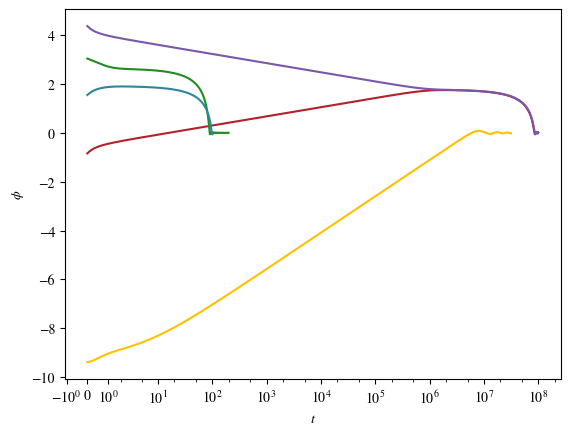

67.37851781685679
66.9901529899047
67.80503632987148
66.83255008781879
67.70502136340171


In [9]:
### check to see that all have reached end of inflation
pl.figure()
pl.plot(sol_f1.t,phit1,color=colors[0])
pl.plot(sol_f1_down.t,phit1_down,color=colors[1])
pl.plot(sol_f2.t,phit2,color=colors[2])
pl.plot(sol_f3.t,phit3,color=colors[3])
pl.plot(sol_f3_down.t,phit3_down,color=colors[4])
pl.xscale('asinh')
pl.xlabel(r'$t$')
pl.ylabel(r'$\phi$')
pl.show()

#### and number of efolds at end of inflation
print(lna1[iend1])
print(lna1_down[iend1_down])
print(lna2[iend2])
print(lna3[iend3])
print(lna3_down[iend3_down])

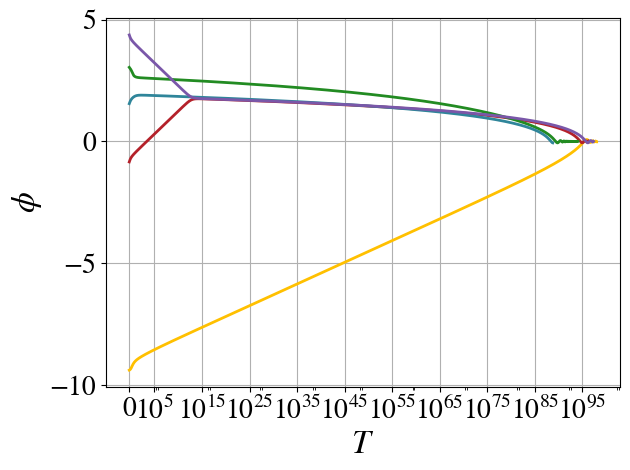

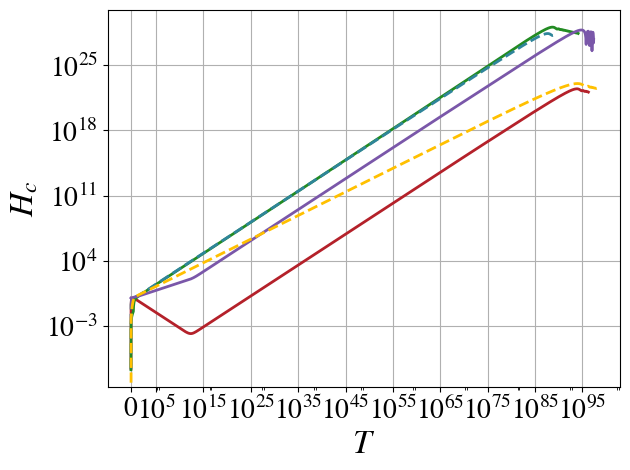

In [16]:
#### background plots

pl.figure()
pl.plot(Tt1,phit1,linewidth=lw,color=colors[0])
pl.plot(Tt1_down,phit1_down,linewidth=lw,color=colors[1])
pl.plot(Tt2,phit2,linewidth=lw,color=colors[2])
pl.plot(Tt3,phit3,linewidth=lw,color=colors[3])
pl.plot(Tt3_down,phit3_down,linewidth=lw,color=colors[4])
pl.xscale('asinh')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$\phi$',fontsize = fontsizeaxlabel)
pl.tick_params(axis = 'both',labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,102,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-phiT.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()

pl.figure()
pl.plot(Tt1,aHt1,'--',linewidth=lw,color=colors[0],zorder=3)
pl.plot(Tt1_down,aHt1_down,linewidth=lw,color=colors[1],zorder=2)
pl.plot(Tt2,aHt2,linewidth=lw,color=colors[2])
pl.plot(Tt3,aHt3,'--',linewidth=lw,color=colors[3])
pl.plot(Tt3_down,aHt3_down,linewidth=lw,color=colors[4])
pl.xscale('asinh')
pl.yscale('log')
pl.xlabel(r'$T$',fontsize = fontsizeaxlabel)
pl.ylabel(r'$H_c$',fontsize = fontsizeaxlabel)
pl.tick_params(axis = 'both',labelsize = fontsizeticks)
pl.xticks([0,]+[10.**n for n in range(5,102,10)])
pl.tight_layout()
pl.grid()
## uncomment to save plot
#fname = root+pot+'-aHT.pdf'
#pl.savefig(fname,dpi = 250, transparent=True)
pl.show()

/tmp/ipykernel_7551/2691355883.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


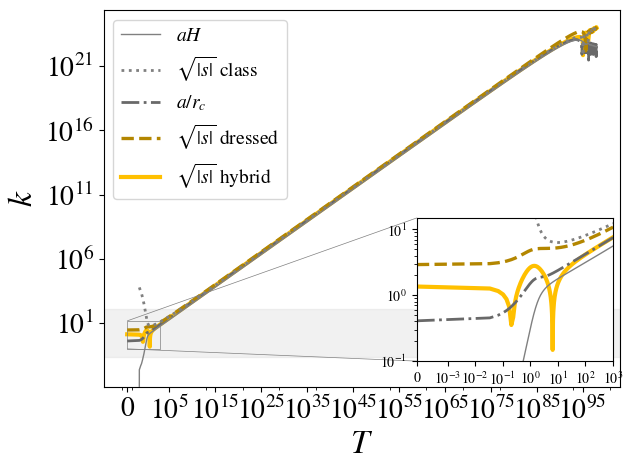

In [14]:
c = colors[0] # main colour of this plot
fig, ax = pl.subplots()

# Manage visual hierarchy via zorder zorder=1 (background), zorder=2,3 (foreground)

# References
ax.plot(Tt1, aHt1, color='gray', linewidth=lw*0.5, label=r'$aH$', zorder=3)
ax.plot(Tt1, np.sqrt(np.abs(zppzt1)), color="gray", linestyle=':', linewidth=lw, label=r'$\sqrt{|s|}$ class', zorder=3)
ax.plot(Tt1, 1/com_rct1, color="dimgray", linestyle='-.', linewidth=lw, label=r'$a/r_c$', zorder=2)

# Core EOM results
ax.plot(Tt1, np.sqrt(np.abs(zppzt1_d)), color=adjust_lightness(c, 0.7), linestyle='--', linewidth=lw*1.2, label=r'$\sqrt{|s|}$ dressed', zorder=2)
ax.plot(Tt1, np.sqrt(np.abs(zppzt1_h)), color=c, linestyle='-', linewidth=lw*1.5, label=r'$\sqrt{|s|}$ hybrid', zorder=1)

# Axis configuration
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_ylabel(r'$k$', fontsize=fontsizeaxlabel)
ax.set_xlabel(r'$T$', fontsize=fontsizeaxlabel)
ax.set_xticks([0,]+[10.**n for n in range(5,102,10)])
ax.tick_params(axis='both', labelsize=fontsizeticks)
ax.axhspan(kmin1, kmax1, color='lightgray', alpha=0.3, zorder=0)
ax.legend(fontsize=fontsizelegend)

# Zoomed inset
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', 
                   bbox_to_anchor=(0.05, 0.05, 0.95, 0.95), 
                   bbox_transform=ax.transAxes)

# Plot data in inset (same order as main for consistency)
axins.plot(Tt1, np.sqrt(np.abs(zppzt1_h)), color=c, linestyle='-', linewidth=lw*1.5)
axins.plot(Tt1, np.sqrt(np.abs(zppzt1_d)), color=adjust_lightness(c, 0.7), linestyle='--', linewidth=lw*1.2)
axins.plot(Tt1, 1/com_rct1, color="dimgray", linestyle='-.', linewidth=lw)
axins.plot(Tt1, aHt1, color='gray', linewidth=lw*0.5)
axins.plot(Tt1, np.sqrt(np.abs(zppzt1)), color="gray", linestyle=':', linewidth=lw)

axins.set_xscale('symlog', linthresh=1e-3)
axins.set_yscale('log')
axins.set_xlim(0, 1e3)
axins.set_ylim(1e-1, 1.5e1)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.5)

pl.tight_layout()
## uncomment to save plot
#fname = root+pot+'-s1.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()

/tmp/ipykernel_7551/1823941162.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


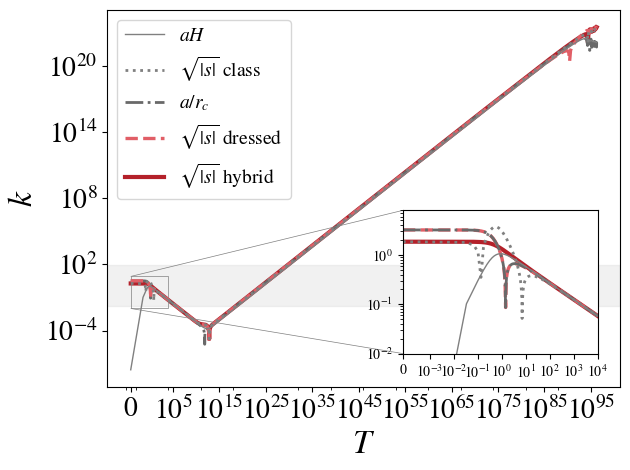

In [17]:
c = colors[1]
fig, ax = pl.subplots()

# Manage visual hierarchy via zorder zorder=1 (background), zorder=2,3 (foreground)

# References
ax.plot(Tt1_down, aHt1_down, color='gray', linewidth=lw*0.5, label=r'$aH$', zorder=3)
ax.plot(Tt1_down, np.sqrt(np.abs(zppzt1_down)), color="gray", linestyle=':', linewidth=lw, label=r'$\sqrt{|s|}$ class', zorder=3)
ax.plot(Tt1_down, 1/com_rct1_down, color="dimgray", linestyle='-.', linewidth=lw, label=r'$a/r_c$', zorder=2)

# Core EOM results
ax.plot(Tt1_down, np.sqrt(np.abs(zppzt1_d_down)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2, label=r'$\sqrt{|s|}$ dressed', zorder=2)
ax.plot(Tt1_down, np.sqrt(np.abs(zppzt1_h_down)), color=c, linestyle='-', linewidth=lw*1.5, label=r'$\sqrt{|s|}$ hybrid', zorder=1)

# Axis configuration
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_ylabel(r'$k$', fontsize=fontsizeaxlabel)
ax.set_xlabel(r'$T$', fontsize=fontsizeaxlabel)
ax.set_xticks([0,] + [10.**n for n in range(5, 101, 10)])
ax.tick_params(axis='both', labelsize=fontsizeticks)
ax.axhspan(kmin1_down, kmax1_down, color='lightgray', alpha=0.3, zorder=0)
ax.legend(fontsize=fontsizelegend)

# Zoomed inset
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', 
                   bbox_to_anchor=(0.02, 0.07, 0.95, 0.95), 
                   bbox_transform=ax.transAxes)

# Plot data in inset (same order as main for consistency)
axins.plot(Tt1_down, np.sqrt(np.abs(zppzt1_h_down)), color=c, linestyle='-', linewidth=lw*1.5)
axins.plot(Tt1_down, np.sqrt(np.abs(zppzt1_d_down)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2)
axins.plot(Tt1_down, 1/com_rct1_down, color="dimgray", linestyle='-.', linewidth=lw)
axins.plot(Tt1_down, aHt1_down, color='gray', linewidth=lw*0.5)
axins.plot(Tt1_down, np.sqrt(np.abs(zppzt1_down)), color="gray", linestyle=':', linewidth=lw)

axins.set_xscale('symlog', linthresh=1e-3)
axins.set_yscale('log')
axins.set_xlim(0, 1e4)
axins.set_ylim(1e-2, 8)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.5)

pl.tight_layout()

## uncomment to save plot
#fname = root+pot+'-s1_down.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()

/tmp/ipykernel_7551/2869508720.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


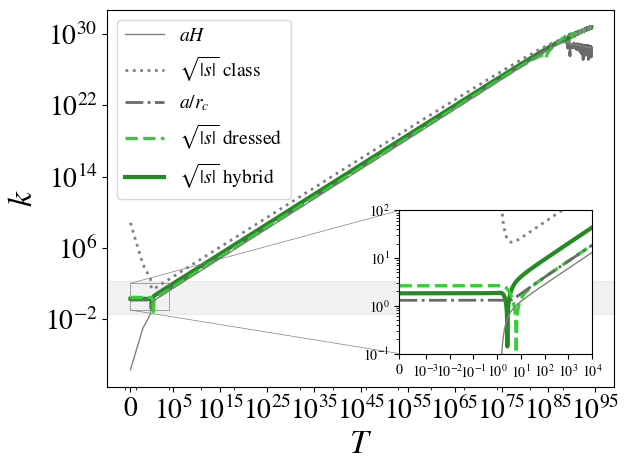

In [18]:
c = colors[2]
fig, ax = pl.subplots()

# Manage visual hierarchy via zorder zorder=1 (background), zorder=2,3 (foreground)

# References
ax.plot(Tt2, aHt2, color='gray', linewidth=lw*0.5, label=r'$aH$', zorder=3)
ax.plot(Tt2, np.sqrt(np.abs(zppzt2)), color="gray", linestyle=':', linewidth=lw, label=r'$\sqrt{|s|}$ class', zorder=3)
ax.plot(Tt2, 1/com_rct2, color="dimgray", linestyle='-.', linewidth=lw, label=r'$a/r_c$', zorder=2)

# Core EOM results
ax.plot(Tt2, np.sqrt(np.abs(zppzt2_d)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2, label=r'$\sqrt{|s|}$ dressed', zorder=2)
ax.plot(Tt2, np.sqrt(np.abs(zppzt2_h)), color=c, linestyle='-', linewidth=lw*1.5, label=r'$\sqrt{|s|}$ hybrid', zorder=1)

# Axis configuration
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_ylabel(r'$k$', fontsize=fontsizeaxlabel)
ax.set_xlabel(r'$T$', fontsize=fontsizeaxlabel)
ax.set_xticks([0,] + [10.**n for n in range(5, 96, 10)])
ax.tick_params(axis='both', labelsize=fontsizeticks)
ax.axhspan(kmin2, kmax2, color='lightgray', alpha=0.3, zorder=0)
ax.legend(fontsize=fontsizelegend)

# Zoomed inset
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', 
                   bbox_to_anchor=(0.02, 0.07, 0.95, 0.95), 
                   bbox_transform=ax.transAxes)

# Plot data in inset (same order as main for consistency)
axins.plot(Tt2, np.sqrt(np.abs(zppzt2_h)), color=c, linestyle='-', linewidth=lw*1.5)
axins.plot(Tt2, np.sqrt(np.abs(zppzt2_d)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2)
axins.plot(Tt2, 1/com_rct2, color="dimgray", linestyle='-.', linewidth=lw)
axins.plot(Tt2, aHt2, color='gray', linewidth=lw*0.5)
axins.plot(Tt2, np.sqrt(np.abs(zppzt2)), color="gray", linestyle=':', linewidth=lw)

axins.set_xscale('symlog', linthresh=1e-3)
axins.set_yscale('log')
axins.set_xlim(0, 1e4)
axins.set_ylim(1e-1, 1e2)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.5)

pl.tight_layout()

## uncomment to save plot
#fname = root+pot+'-s2.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()

/tmp/ipykernel_7551/1476553323.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


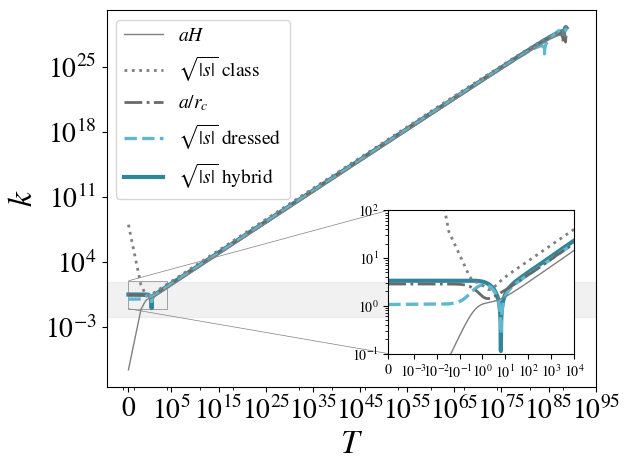

In [19]:
c = colors[3]
fig, ax = pl.subplots()

# Manage visual hierarchy via zorder zorder=1 (background), zorder=2,3 (foreground)

# References (Lower hierarchy)
ax.plot(Tt3, aHt3, color='gray', linewidth=lw*0.5, label=r'$aH$', zorder=3)
ax.plot(Tt3, np.sqrt(np.abs(zppzt3)), color="gray", linestyle=':', linewidth=lw, label=r'$\sqrt{|s|}$ class', zorder=3)
ax.plot(Tt3, 1/com_rct3, color="dimgray", linestyle='-.', linewidth=lw, label=r'$a/r_c$', zorder=2)

# Core EOM results (Higher hierarchy)
ax.plot(Tt3, np.sqrt(np.abs(zppzt3_d)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2, label=r'$\sqrt{|s|}$ dressed', zorder=2)
ax.plot(Tt3, np.sqrt(np.abs(zppzt3_h)), color=c, linestyle='-', linewidth=lw*1.5, label=r'$\sqrt{|s|}$ hybrid', zorder=1)

# Axis configuration
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_ylabel(r'$k$', fontsize=fontsizeaxlabel)
ax.set_xlabel(r'$T$', fontsize=fontsizeaxlabel)
ax.set_xticks([0,] + [10.**n for n in range(5, 96, 10)])
ax.tick_params(axis='both', labelsize=fontsizeticks)
ax.axhspan(kmin3, kmax3, color='lightgray', alpha=0.3, zorder=0)
ax.legend(fontsize=fontsizelegend)

# Zoomed inset
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', 
                   bbox_to_anchor=(0.02, 0.07, 0.95, 0.95), 
                   bbox_transform=ax.transAxes)

# Plot data in inset (same order as main for consistency)
axins.plot(Tt3, np.sqrt(np.abs(zppzt3_h)), color=c, linestyle='-', linewidth=lw*1.5)
axins.plot(Tt3, np.sqrt(np.abs(zppzt3_d)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2)
axins.plot(Tt3, 1/com_rct3, color="dimgray", linestyle='-.', linewidth=lw)
axins.plot(Tt3, aHt3, color='gray', linewidth=lw*0.5)
axins.plot(Tt3, np.sqrt(np.abs(zppzt3)), color="gray", linestyle=':', linewidth=lw)

axins.set_xscale('symlog', linthresh=1e-3)
axins.set_yscale('log')
axins.set_xlim(0, 1e4)
axins.set_ylim(1e-1, 1e2)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.5)

pl.tight_layout()

## uncomment to save plot
#fname = root+pot+'-s3.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()

/tmp/ipykernel_7551/2925946870.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


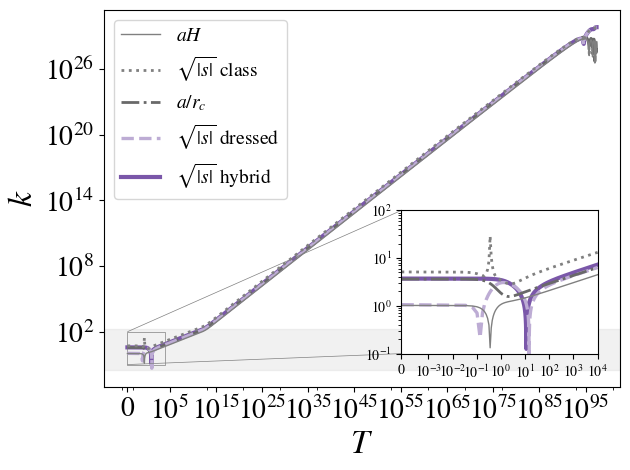

In [20]:
c = colors[4]
fig, ax = pl.subplots()

# Manage visual hierarchy via zorder zorder=1 (background), zorder=2,3 (foreground)

# References
ax.plot(Tt3_down, aHt3_down, color='gray', linewidth=lw*0.5, label=r'$aH$', zorder=3)
ax.plot(Tt3_down, np.sqrt(np.abs(zppzt3_down)), color="gray", linestyle=':', linewidth=lw, label=r'$\sqrt{|s|}$ class', zorder=3)
ax.plot(Tt3_down, 1/com_rct3_down, color="dimgray", linestyle='-.', linewidth=lw, label=r'$a/r_c$', zorder=2)

# Core EOM results
ax.plot(Tt3_down, np.sqrt(np.abs(zppzt3_d_down)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2, label=r'$\sqrt{|s|}$ dressed', zorder=2)
ax.plot(Tt3_down, np.sqrt(np.abs(zppzt3_h_down)), color=c, linestyle='-', linewidth=lw*1.5, label=r'$\sqrt{|s|}$ hybrid', zorder=1)

# Axis configuration
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.set_ylabel(r'$k$', fontsize=fontsizeaxlabel)
ax.set_xlabel(r'$T$', fontsize=fontsizeaxlabel)
ax.set_xticks([0,] + [10.**n for n in range(5, 101, 10)])
ax.tick_params(axis='both', labelsize=fontsizeticks)
ax.axhspan(kmin3_down, kmax3_down, color='lightgray', alpha=0.3, zorder=0)
ax.legend(fontsize=fontsizelegend)

# Zoomed inset
axins = inset_axes(ax, width="40%", height="40%", loc='lower right', 
                   bbox_to_anchor=(0.02, 0.07, 0.95, 0.95), 
                   bbox_transform=ax.transAxes)

# Plot data in inset (same order as main for consistency)
axins.plot(Tt3_down, np.sqrt(np.abs(zppzt3_h_down)), color=c, linestyle='-', linewidth=lw*1.5)
axins.plot(Tt3_down, np.sqrt(np.abs(zppzt3_d_down)), color=adjust_lightness(c, 1.5), linestyle='--', linewidth=lw*1.2)
axins.plot(Tt3_down, 1/com_rct3_down, color="dimgray", linestyle='-.', linewidth=lw)
axins.plot(Tt3_down, aHt3_down, color='gray', linewidth=lw*0.5)
axins.plot(Tt3_down, np.sqrt(np.abs(zppzt3_down)), color="gray", linestyle=':', linewidth=lw)

axins.set_xscale('symlog', linthresh=1e-3)
axins.set_yscale('log')
axins.set_xlim(0, 1e4)
axins.set_ylim(1e-1, 1e2)

# Draw connection lines
mark_inset(ax, axins, loc1=2, loc2=3, fc="none", ec="0.5", lw=0.5)

pl.tight_layout()

## uncomment to save plot
#fname = root+pot+'-s3_down.pdf'
#pl.savefig(fname,dpi = 250)
pl.show()